# Module 1 — Outlier Detection
**Methods:** Local Outlier Factor (LOF) · KNN Distance · HBOS  
**Consensus:** flag as outlier if ≥ 2/3 methods agree  
**Dataset:** cmi_clean.csv

---
## Section 0 — Setup & Shared Feature Matrix

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# ── Load dataset ─────────────────────────────────────────────────
df = pd.read_csv('cmi_clean.csv')
print(f"Dataset shape: {df.shape}")

# ── Drop categorical columns + excluded cols ──────────────────────
# We drop: all object/categorical dtypes, plus these specific cols
exclude_cols = ['sii', 'BIA_measured', 'SDS_measured', 'ScreenTime_Category','Basic_Demos-Sex']

# Select numeric only, then remove excluded cols that are present
feature_cols = [
    c for c in df.select_dtypes(include=np.number).columns
    if c not in exclude_cols
]

print(f"\nFeatures used for all methods: {len(feature_cols)}")
print(feature_cols)

# ── Scale ─────────────────────────────────────────────────────────
# All three methods use distance/density → scaling is mandatory
X = df[feature_cols].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
df.columns

print(f"\nX_scaled shape: {X_scaled.shape}")
print("Scaling applied: mean=0, std=1 per feature")

Dataset shape: (8460, 32)

Features used for all methods: 27
['Basic_Demos-Age', 'CGAS-CGAS_Score', 'Physical-BMI', 'Physical-Height', 'Physical-Weight', 'Physical-Waist_Circumference', 'Physical-Diastolic_BP', 'Physical-HeartRate', 'Physical-Systolic_BP', 'Fitness_Endurance-Max_Stage', 'BIA-BIA_Activity_Level_num', 'BIA-BIA_FFM', 'BIA-BIA_FFMI', 'BIA-BIA_FMI', 'BIA-BIA_Fat', 'BIA-BIA_Frame_num', 'BIA-BIA_SMM', 'SDS-SDS_Total_T', 'PreInt_EduHx-computerinternet_hoursday', 'FGC_Flexibility_Avg', 'FGC_Grip_Avg', 'PAQ_Total', 'FGC_Muscular_Endurance', 'Social_Digital_Displacement', 'Lifestyle_Risk_Score', 'Metabolic_Alarms_Count', 'ScreenTime_Age_Ratio']

X_scaled shape: (8460, 27)
Scaling applied: mean=0, std=1 per feature


In [ ]:
df.columns

Index(['Basic_Demos-Age', 'Basic_Demos-Sex', 'CGAS-CGAS_Score', 'Physical-BMI',
       'Physical-Height', 'Physical-Weight', 'Physical-Waist_Circumference',
       'Physical-Diastolic_BP', 'Physical-HeartRate', 'Physical-Systolic_BP',
       'Fitness_Endurance-Max_Stage', 'BIA-BIA_Activity_Level_num',
       'BIA-BIA_FFM', 'BIA-BIA_FFMI', 'BIA-BIA_FMI', 'BIA-BIA_Fat',
       'BIA-BIA_Frame_num', 'BIA-BIA_SMM', 'SDS-SDS_Total_T',
       'PreInt_EduHx-computerinternet_hoursday', 'sii', 'FGC_Flexibility_Avg',
       'FGC_Grip_Avg', 'PAQ_Total', 'SDS_measured', 'BIA_measured',
       'FGC_Muscular_Endurance', 'Social_Digital_Displacement',
       'Lifestyle_Risk_Score', 'Metabolic_Alarms_Count',
       'ScreenTime_Age_Ratio', 'ScreenTime_Category'],
      dtype='object')

---
## Section 1 — LOF (Local Outlier Factor)
Density-based method. Compares local density of a point to its neighbours.  
High LOF score = point is in a much sparser region than its neighbours → outlier.

In [ ]:
from sklearn.neighbors import LocalOutlierFactor

contamination = 0.01  # top 1% across all methods

# ── k selection: test k = 10, 20, 50 ─────────────────────────────
# k=10 → unstable (extreme scores from duplicate values)
# k=20 → balanced: stable scores, local sensitivity preserved
# k=50 → too global, misses local anomalies
k_values = [10, 20, 50]
print(f"{'k':>5} {'Outliers':>10} {'Min LOF':>10} {'Max LOF':>10} {'Mean LOF':>10}")
print("-" * 50)

for k in k_values:
    lof = LocalOutlierFactor(n_neighbors=k, contamination=contamination)
    labels = lof.fit_predict(X_scaled)
    scores = -lof.negative_outlier_factor_
    print(f"{k:>5} {(labels==-1).sum():>10} {scores.min():>10.3f} {scores.max():>10.3f} {scores.mean():>10.3f}")

    k   Outliers    Min LOF    Max LOF   Mean LOF
--------------------------------------------------


/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_lof.py:322: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(


   10         85      0.948 13214973442.949 7958586.414
   20         85      0.941      9.684      1.399
   50         85      0.966      7.554      1.416


In [ ]:
# ── Final LOF: k=20 ───────────────────────────────────────────────
best_k = 20
lof_final = LocalOutlierFactor(n_neighbors=best_k, contamination=contamination)
lof_labels = lof_final.fit_predict(X_scaled)       # -1 = outlier, 1 = normal
lof_scores = -lof_final.negative_outlier_factor_   # higher = more anomalous

df['LOF_score']   = lof_scores
df['LOF_outlier'] = (lof_labels == -1).astype(int)

print(f"LOF (k={best_k}) — Outliers: {df['LOF_outlier'].sum()}")
print(f"Score range: {lof_scores.min():.3f} – {lof_scores.max():.3f}")

print(f"\nsii distribution in LOF outliers:")
print(df[df['LOF_outlier']==1]['sii'].value_counts().sort_index())

LOF (k=20) — Outliers: 85
Score range: 0.941 – 9.684

sii distribution in LOF outliers:
sii
0.0    72
1.0     5
2.0     8
Name: count, dtype: int64


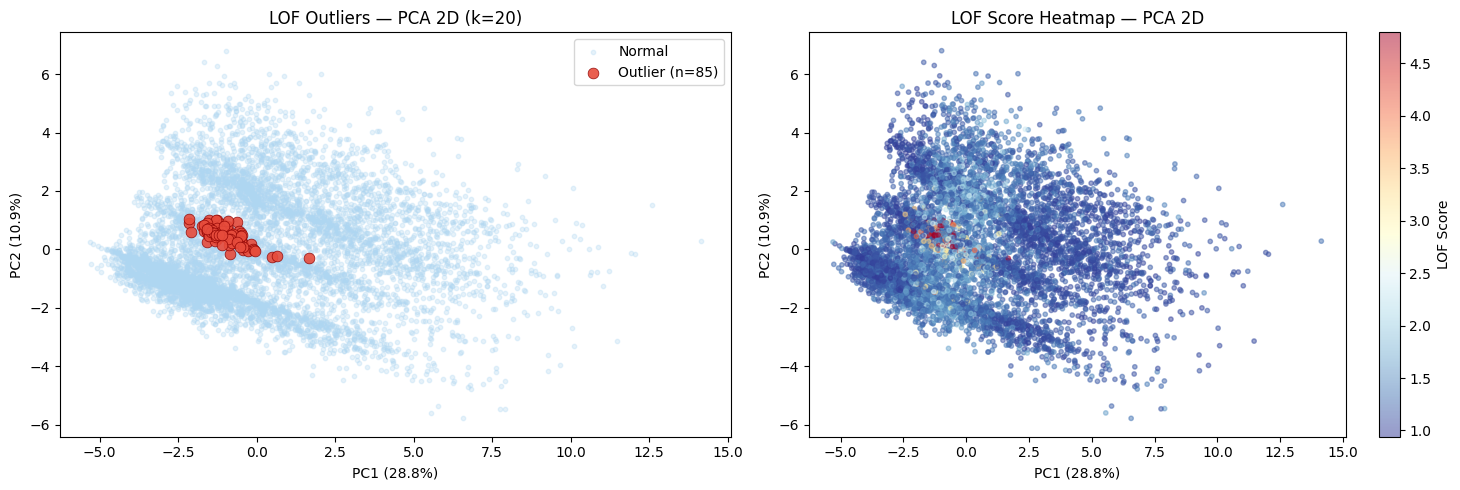

In [ ]:
# ── LOF visualisation ─────────────────────────────────────────────
pca2 = PCA(n_components=2, random_state=42)
X_pca = pca2.fit_transform(X_scaled)
explained = pca2.explained_variance_ratio_

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: outlier labels
axes[0].scatter(X_pca[lof_labels== 1, 0], X_pca[lof_labels== 1, 1],
                c='#AED6F1', s=10, alpha=0.3, label='Normal')
axes[0].scatter(X_pca[lof_labels==-1, 0], X_pca[lof_labels==-1, 1],
                c='#E74C3C', s=60, alpha=0.9, label=f'Outlier (n={df["LOF_outlier"].sum()})',
                edgecolors='darkred', linewidth=0.5)
axes[0].set_xlabel(f'PC1 ({explained[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({explained[1]*100:.1f}%)')
axes[0].set_title(f'LOF Outliers — PCA 2D (k={best_k})')
axes[0].legend()

# Plot 2: LOF score heatmap
sc = axes[1].scatter(X_pca[:, 0], X_pca[:, 1],
                     c=lof_scores, cmap='RdYlBu_r',
                     s=10, alpha=0.5, vmax=np.percentile(lof_scores, 99))
plt.colorbar(sc, ax=axes[1], label='LOF Score')
axes[1].set_xlabel(f'PC1 ({explained[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({explained[1]*100:.1f}%)')
axes[1].set_title('LOF Score Heatmap — PCA 2D')

plt.tight_layout()
plt.savefig('lof_pca.png', dpi=150)
plt.show()

---
## Section 2 — KNN Distance
Distance-based method. Anomaly score = distance to k-th nearest neighbour.  
High score = point is far from its neighbours → global outlier.

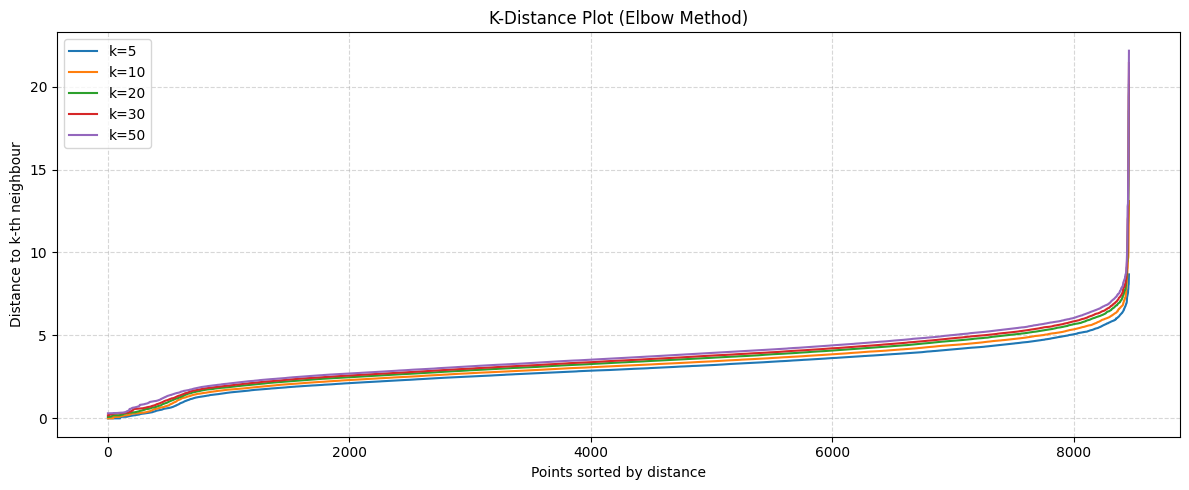

99th percentile thresholds per k:
  k=5: 6.1311
  k=10: 6.5994
  k=20: 6.9532
  k=30: 7.2463
  k=50: 7.5200


In [ ]:
from sklearn.neighbors import NearestNeighbors

# ── Elbow plot: choose k ──────────────────────────────────────────
k_values = [5, 10, 20, 30, 50]
plt.figure(figsize=(12, 5))

for k in k_values:
    nbrs = NearestNeighbors(n_neighbors=k).fit(X_scaled)
    distances, _ = nbrs.kneighbors(X_scaled)
    k_dist = np.sort(distances[:, k-1])
    plt.plot(k_dist, label=f'k={k}')

plt.title('K-Distance Plot (Elbow Method)')
plt.xlabel('Points sorted by distance')
plt.ylabel('Distance to k-th neighbour')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('knn_elbow.png', dpi=150)
plt.show()

print("99th percentile thresholds per k:")
for k in k_values:
    nbrs = NearestNeighbors(n_neighbors=k).fit(X_scaled)
    distances, _ = nbrs.kneighbors(X_scaled)
    thresh = np.percentile(distances[:, k-1], 99)
    print(f"  k={k}: {thresh:.4f}")

In [ ]:
# ── Final KNN: k=30 ───────────────────────────────────────────────
# k=30 chosen: stable threshold, consistent with LOF neighbourhood size
k_knn = 30
nbrs = NearestNeighbors(n_neighbors=k_knn).fit(X_scaled)
distances, _ = nbrs.kneighbors(X_scaled)
knn_scores = distances[:, k_knn - 1]  # distance to k-th neighbour

threshold_knn = np.percentile(knn_scores, 99)  # top 1%

df['KNN_score']   = knn_scores
df['KNN_outlier'] = (knn_scores > threshold_knn).astype(int)

print(f"KNN (k={k_knn}) — Threshold (99th pct): {threshold_knn:.4f}")
print(f"Outliers: {df['KNN_outlier'].sum()}")
print(f"\nsii distribution in KNN outliers:")
print(df[df['KNN_outlier']==1]['sii'].value_counts().sort_index())

KNN (k=30) — Threshold (99th pct): 7.2463
Outliers: 85

sii distribution in KNN outliers:
sii
0.0    50
1.0    17
2.0    14
3.0     4
Name: count, dtype: int64


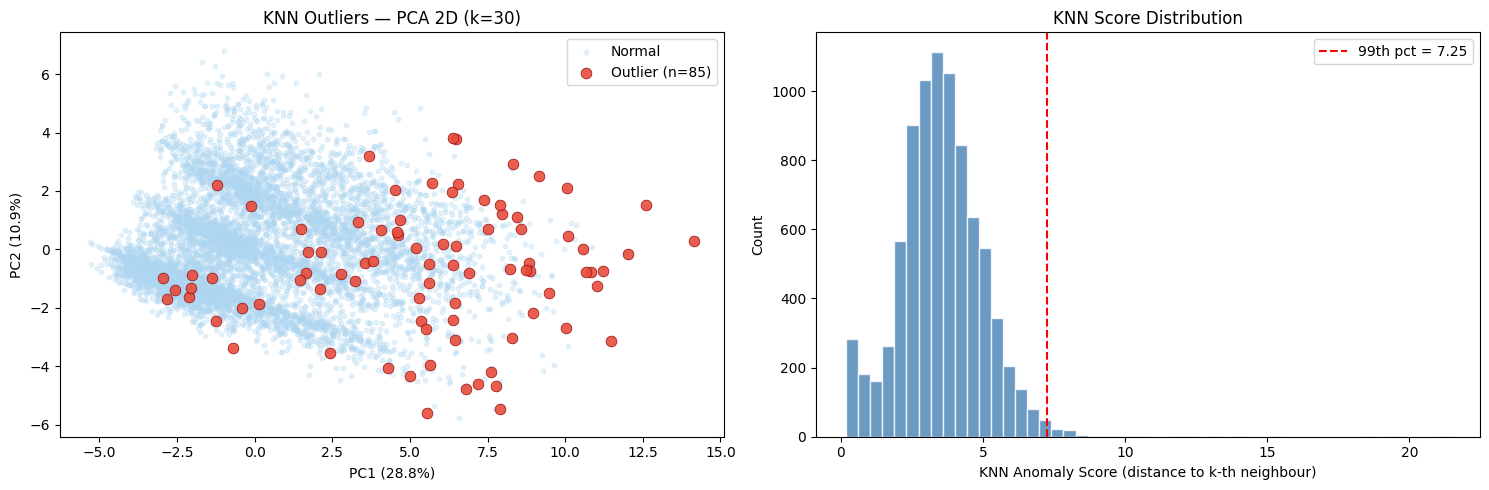

In [ ]:
# ── KNN visualisation ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

knn_labels_plot = np.where(df['KNN_outlier'] == 1, -1, 1)

axes[0].scatter(X_pca[knn_labels_plot== 1, 0], X_pca[knn_labels_plot== 1, 1],
                c='#AED6F1', s=10, alpha=0.3, label='Normal')
axes[0].scatter(X_pca[knn_labels_plot==-1, 0], X_pca[knn_labels_plot==-1, 1],
                c='#E74C3C', s=60, alpha=0.9, label=f'Outlier (n={df["KNN_outlier"].sum()})',
                edgecolors='darkred', linewidth=0.5)
axes[0].set_xlabel(f'PC1 ({explained[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({explained[1]*100:.1f}%)')
axes[0].set_title(f'KNN Outliers — PCA 2D (k={k_knn})')
axes[0].legend()

# Score histogram
axes[1].hist(knn_scores, bins=50, color='steelblue', edgecolor='white', alpha=0.8)
axes[1].axvline(threshold_knn, color='red', linestyle='--', label=f'99th pct = {threshold_knn:.2f}')
axes[1].set_xlabel('KNN Anomaly Score (distance to k-th neighbour)')
axes[1].set_ylabel('Count')
axes[1].set_title('KNN Score Distribution')
axes[1].legend()

plt.tight_layout()
plt.savefig('knn_pca.png', dpi=150)
plt.show()

---
## Section 3 — HBOS (Histogram-Based Outlier Score)
Statistical method. Builds independent histograms per feature; anomaly score = product of inverse bin probabilities.  
**Why PCA first?** HBOS assumes features are independent when combining per-feature scores. Our original features are heavily correlated (BMI, Weight, Height, Waist all move together), which inflates certain histogram scores. PCA produces orthogonal (uncorrelated) components, which better satisfies this assumption and reduces noise.  
Fast and effective on high-dimensional data.

In [ ]:
!pip install pyod -q
from pyod.models.hbos import HBOS

# ── PCA for HBOS: reduce to 95% variance ─────────────────────────
# Original features are correlated (BMI/Weight/Height etc.) — PCA creates
# orthogonal components, better matching HBOS's independence assumption
pca_hbos = PCA(n_components=0.95, random_state=42)
X_pca_hbos = pca_hbos.fit_transform(X_scaled)

print(f"HBOS PCA components selected: {X_pca_hbos.shape[1]}")
print(f"Variance explained: {sum(pca_hbos.explained_variance_ratio_)*100:.2f}%")

X_pca_hbos_df = pd.DataFrame(X_pca_hbos, columns=[f'PC{i+1}' for i in range(X_pca_hbos.shape[1])])

# ── Fit HBOS ──────────────────────────────────────────────────────
hbos = HBOS(contamination=0.01)
hbos.fit(X_pca_hbos_df)

df['HBOS_score']   = hbos.decision_scores_
df['HBOS_outlier'] = hbos.labels_  # 1 = outlier, 0 = normal

print(f"\nHBOS — Outliers: {df['HBOS_outlier'].sum()}")
print(f"Score range: {df['HBOS_score'].min():.3f} – {df['HBOS_score'].max():.3f}")
print(f"\nsii distribution in HBOS outliers:")
print(df[df['HBOS_outlier']==1]['sii'].value_counts().sort_index())

HBOS PCA components selected: 20
Variance explained: 95.79%

HBOS — Outliers: 85
Score range: 18.881 – 52.450

sii distribution in HBOS outliers:
sii
0.0    47
1.0    21
2.0    12
3.0     5
Name: count, dtype: int64


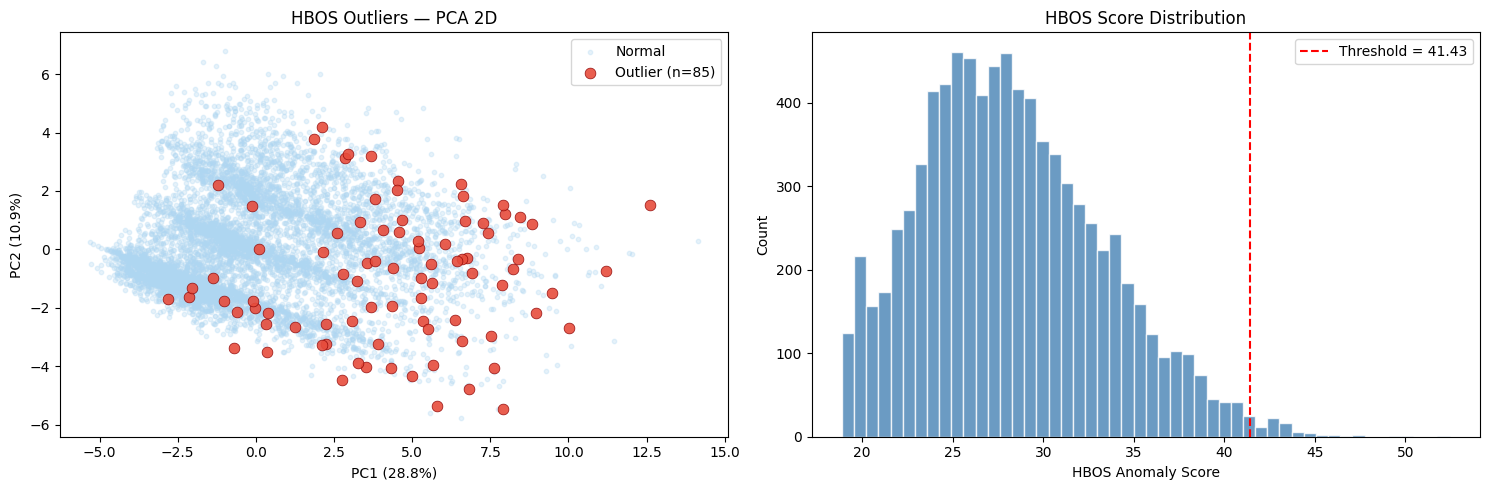

In [ ]:
# ── HBOS visualisation ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

hbos_labels_plot = np.where(df['HBOS_outlier'] == 1, -1, 1)

axes[0].scatter(X_pca[hbos_labels_plot== 1, 0], X_pca[hbos_labels_plot== 1, 1],
                c='#AED6F1', s=10, alpha=0.3, label='Normal')
axes[0].scatter(X_pca[hbos_labels_plot==-1, 0], X_pca[hbos_labels_plot==-1, 1],
                c='#E74C3C', s=60, alpha=0.9, label=f'Outlier (n={df["HBOS_outlier"].sum()})',
                edgecolors='darkred', linewidth=0.5)
axes[0].set_xlabel(f'PC1 ({explained[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({explained[1]*100:.1f}%)')
axes[0].set_title('HBOS Outliers — PCA 2D')
axes[0].legend()

# Score histogram
threshold_hbos = df[df['HBOS_outlier']==1]['HBOS_score'].min()
axes[1].hist(df['HBOS_score'], bins=50, color='steelblue', edgecolor='white', alpha=0.8)
axes[1].axvline(threshold_hbos, color='red', linestyle='--', label=f'Threshold = {threshold_hbos:.2f}')
axes[1].set_xlabel('HBOS Anomaly Score')
axes[1].set_ylabel('Count')
axes[1].set_title('HBOS Score Distribution')
axes[1].legend()

plt.tight_layout()
plt.savefig('hbos_pca.png', dpi=150)
plt.show()

---
## Section 4 — Consensus Ensemble
Flag a point as a confirmed outlier if **at least 2 out of 3** methods agree.

In [ ]:
# ── Vote count ────────────────────────────────────────────────────
df['vote_count']       = df['LOF_outlier'] + df['KNN_outlier'] + df['HBOS_outlier']
df['consensus_outlier'] = (df['vote_count'] >= 2).astype(int)

print("=" * 45)
print("ENSEMBLE CONSENSUS SUMMARY")
print("=" * 45)
print(f"Flagged by all 3 methods:    {(df['vote_count']==3).sum()}")
print(f"Flagged by exactly 2:        {(df['vote_count']==2).sum()}")
print(f"Flagged by exactly 1:        {(df['vote_count']==1).sum()}")
print(f"Flagged by none:             {(df['vote_count']==0).sum()}")
print(f"\nCONFIRMED OUTLIERS (≥2/3):   {df['consensus_outlier'].sum()}")
print(f"Clean rows kept:             {(df['consensus_outlier']==0).sum()}")

print(f"\nsii distribution in CONSENSUS outliers:")
print(df[df['consensus_outlier']==1]['sii'].value_counts().sort_index())
print(f"\nsii distribution in CLEAN rows:")
print(df[df['consensus_outlier']==0]['sii'].value_counts().sort_index())

ENSEMBLE CONSENSUS SUMMARY
Flagged by all 3 methods:    0
Flagged by exactly 2:        42
Flagged by exactly 1:        171
Flagged by none:             8247

CONFIRMED OUTLIERS (≥2/3):   42
Clean rows kept:             8418

sii distribution in CONSENSUS outliers:
sii
0.0    26
1.0     9
2.0     5
3.0     2
Name: count, dtype: int64

sii distribution in CLEAN rows:
sii
0.0    5807
1.0    1578
2.0     947
3.0      86
Name: count, dtype: int64


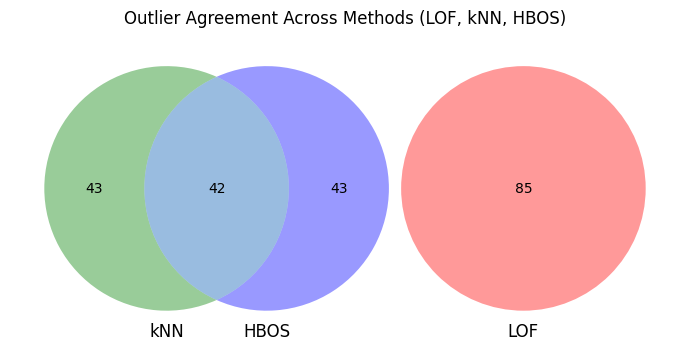

LOF only: 85
kNN only: 43
HBOS only: 43
LOF ∩ kNN: 0
LOF ∩ HBOS: 0
kNN ∩ HBOS: 42
LOF ∩ kNN ∩ HBOS: 0


In [ ]:
from matplotlib_venn import venn3
import matplotlib.pyplot as plt

# ── Create sets ────────────────────────────────────────────────
set_lof  = set(df[df['LOF_outlier']  == 1].index)
set_knn  = set(df[df['KNN_outlier']  == 1].index)
set_hbos = set(df[df['HBOS_outlier'] == 1].index)

# ── Plot Venn diagram ──────────────────────────────────────────
plt.figure(figsize=(7, 6))

venn = venn3(
    [set_lof, set_knn, set_hbos],
    set_labels=('LOF', 'kNN', 'HBOS')
)

# Optional: improve label readability
for text in venn.set_labels:
    if text:
        text.set_fontsize(12)

for text in venn.subset_labels:
    if text:
        text.set_fontsize(10)

plt.title('Outlier Agreement Across Methods (LOF, kNN, HBOS)')
plt.tight_layout()

# Save + show
plt.savefig('venn_consensus.png', dpi=150)
plt.show()
lof_only = len(set_lof - set_knn - set_hbos)
knn_only = len(set_knn - set_lof - set_hbos)
hbos_only = len(set_hbos - set_lof - set_knn)
lof_knn = len((set_lof & set_knn) - set_hbos)
lof_hbos = len((set_lof & set_hbos) - set_knn)
knn_hbos = len((set_knn & set_hbos) - set_lof)
all_three = len(set_lof & set_knn & set_hbos)

print("LOF only:", lof_only)
print("kNN only:", knn_only)
print("HBOS only:", hbos_only)
print("LOF ∩ kNN:", lof_knn)
print("LOF ∩ HBOS:", lof_hbos)
print("kNN ∩ HBOS:", knn_hbos)
print("LOF ∩ kNN ∩ HBOS:", all_three)

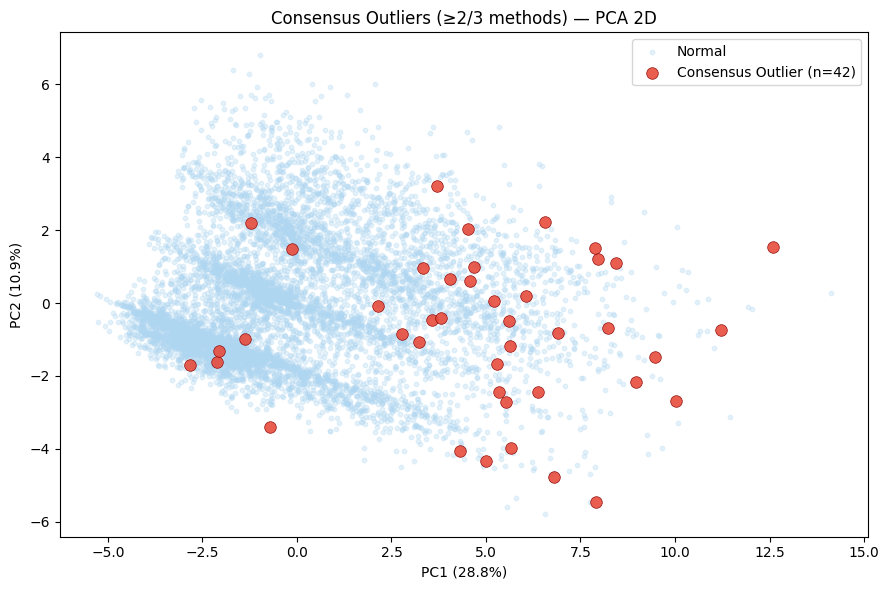

In [ ]:
# ── Consensus PCA visualisation ───────────────────────────────────
consensus_labels = np.where(df['consensus_outlier'] == 1, -1, 1)

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(X_pca[consensus_labels== 1, 0], X_pca[consensus_labels== 1, 1],
           c='#AED6F1', s=10, alpha=0.3, label='Normal')
ax.scatter(X_pca[consensus_labels==-1, 0], X_pca[consensus_labels==-1, 1],
           c='#E74C3C', s=70, alpha=0.9, label=f'Consensus Outlier (n={df["consensus_outlier"].sum()})',
           edgecolors='darkred', linewidth=0.5)
ax.set_xlabel(f'PC1 ({explained[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({explained[1]*100:.1f}%)')
ax.set_title('Consensus Outliers (≥2/3 methods) — PCA 2D')
ax.legend()
plt.tight_layout()
plt.savefig('consensus_pca.png', dpi=150)
plt.show()

Top features driving outlier status:
                                        Normal mean  Outlier mean  Difference %
FGC_Muscular_Endurance                        6.957        20.327         192.2
Metabolic_Alarms_Count                        0.589         1.310         122.4
FGC_Grip_Avg                                 20.203        41.558         105.7
BIA-BIA_FMI                                   4.613         8.129          76.2
Social_Digital_Displacement                   0.132         0.227          72.0
Physical-Weight                              84.259       140.984          67.3
PreInt_EduHx-computerinternet_hoursday        0.980         1.571          60.3
Fitness_Endurance-Max_Stage                   4.937         7.095          43.7
Physical-BMI                                 19.388        26.865          38.6
BIA-BIA_SMM                                  30.641        41.351          35.0
Basic_Demos-Age                              10.223        13.762          34.6
BIA

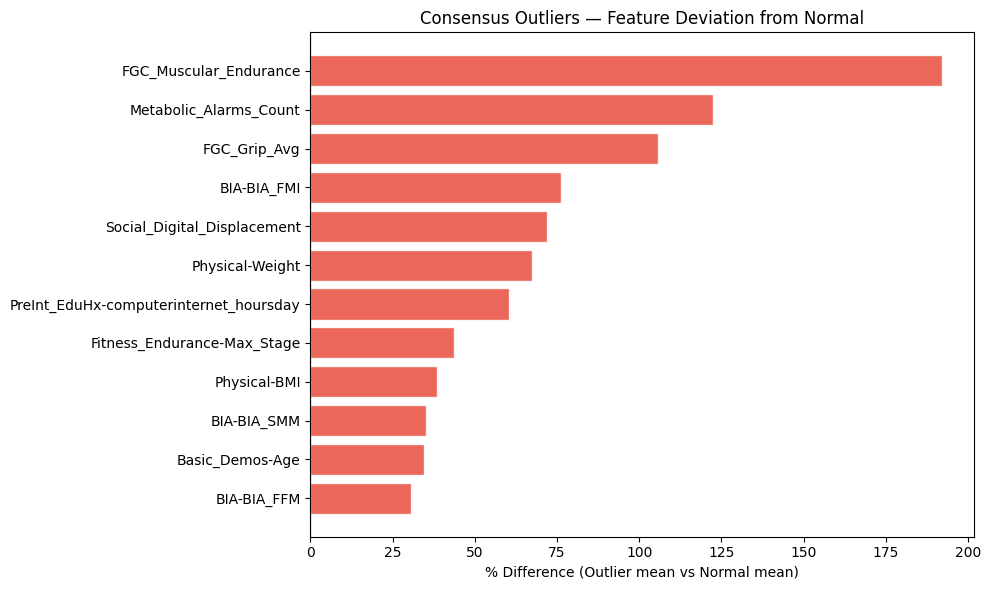

In [ ]:
# ── Feature comparison: outliers vs normal ────────────────────────
outliers_df = df[df['consensus_outlier'] == 1]
normal_df   = df[df['consensus_outlier'] == 0]

comparison = pd.DataFrame({
    'Normal mean':  normal_df[feature_cols].mean(),
    'Outlier mean': outliers_df[feature_cols].mean(),
}).round(3)
comparison['Difference %'] = (
    (comparison['Outlier mean'] - comparison['Normal mean'])
    / comparison['Normal mean'].abs() * 100
).round(1)
comparison = comparison.reindex(
    comparison['Difference %'].abs().sort_values(ascending=False).index
)

print("Top features driving outlier status:")
print(comparison.head(15).to_string())

# Bar chart
top_diff = comparison.head(12)
colors = ['#E74C3C' if x > 0 else '#3498DB' for x in top_diff['Difference %']]
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top_diff.index, top_diff['Difference %'], color=colors, alpha=0.85, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('% Difference (Outlier mean vs Normal mean)')
ax.set_title('Consensus Outliers — Feature Deviation from Normal')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('consensus_feature_diff.png', dpi=150)
plt.show()

In [ ]:
# Rows where BOTH kNN and HBOS agree
knn_hbos_overlap = df[(df['KNN_outlier'] == 1) & (df['HBOS_outlier'] == 1)]

print(f"Number of overlapping outliers (kNN ∩ HBOS): {len(knn_hbos_overlap)}")

# View them
knn_hbos_overlap.head(30)

Number of overlapping outliers (kNN ∩ HBOS): 42


,Basic_Demos-Age,Basic_Demos-Sex,CGAS-CGAS_Score,Physical-BMI,Physical-Height,Physical-Weight,Physical-Waist_Circumference,Physical-Diastolic_BP,Physical-HeartRate,Physical-Systolic_BP,...,ScreenTime_Age_Ratio,ScreenTime_Category,LOF_score,LOF_outlier,KNN_score,KNN_outlier,HBOS_score,HBOS_outlier,vote_count,consensus_outlier
59,17,0,65.0,24.446886,68.000,160.80,33.00,81.0,56.0,123.0,...,0.055556,1,1.524572,0,12.002721,1,52.450217,1,2,1
87,17,0,65.0,26.630764,77.000,224.60,37.00,72.0,71.0,144.0,...,0.111111,1,1.333256,0,7.417269,1,43.552832,1,2,1
489,17,0,70.0,35.017194,69.500,240.60,36.60,100.0,102.0,166.0,...,0.000000,0,1.576948,0,9.590630,1,46.582470,1,2,1
617,16,1,65.0,20.028327,70.000,139.60,28.00,71.0,68.0,114.0,...,0.117647,1,1.195597,0,7.944532,1,45.218242,1,2,1
672,13,0,80.0,22.871305,58.200,110.20,26.00,70.0,120.0,118.0,...,0.142857,1,1.519521,0,7.891755,1,45.772077,1,2,1
785,12,0,65.0,39.221392,61.000,207.60,26.00,64.0,104.0,141.0,...,0.230769,2,1.311425,0,7.787720,1,43.182220,1,2,1
896,17,0,65.0,20.339299,70.500,143.80,30.00,83.0,133.0,153.0,...,0.111111,1,1.519151,0,7.773966,1,42.324180,1,2,1
921,16,0,50.0,53.918413,62.500,299.60,43.60,68.0,81.0,114.0,...,0.176471,2,1.351308,0,9.778139,1,42.918671,1,2,1
994,14,0,70.0,20.883425,66.000,129.40,26.00,59.0,66.0,127.0,...,0.133333,1,1.266072,0,8.146001,1,42.346418,1,2,1
1030,14,0,65.0,19.943262,70.500,141.00,29.00,67.0,60.0,118.0,...,0.133333,1,1.186466,0,7.569924,1,41.477366,1,2,1


---
## Section 5 — Treatment Decision

Run the cell below **first** to see the sii breakdown, then pick your strategy.

### Options:

| Option | What it does | When to use |
|--------|-------------|-------------|
| **A — Remove** | Drop consensus outlier rows entirely | Outliers are concentrated in sii=0/1 (mild); few severe cases lost |
| **B — Keep + flag** | Add `consensus_outlier` as a feature, train on everything | Outliers spread across all sii classes; you can't afford to lose severe cases |
| **C — Winsorize** | Clip feature values to 1st/99th percentile — keeps rows, tames extremes | Outliers are valid children but extreme on a few features |

**How to decide:** look at the sii distribution printed above.  
- If outliers are mostly sii=0/1 → **Option A** is safe  
- If outliers include many sii=2/3 → **Option B** (you'd lose rare severe cases if you remove)  
- If you're unsure → **Option C** is the safest middle ground

Total rows:          8460
Consensus outliers:  42 (0.5%)

sii in OUTLIERS:
sii
0.0    61.9
1.0    21.4
2.0    11.9
3.0     4.8
Name: proportion, dtype: float64

sii in NORMAL rows:
sii
0.0    69.0
1.0    18.7
2.0    11.2
3.0     1.0
Name: proportion, dtype: float64


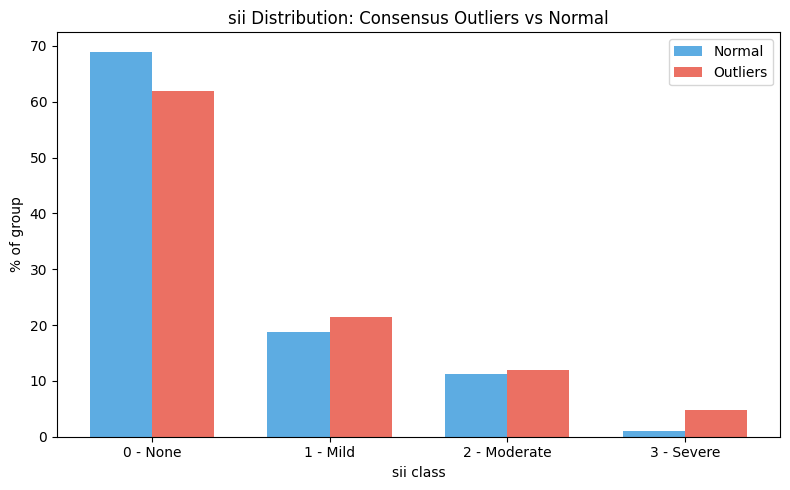

In [ ]:
# ── Decision check: sii breakdown in outliers ────────────────────
total = len(df)
n_out = df['consensus_outlier'].sum()

print(f"Total rows:          {total}")
print(f"Consensus outliers:  {n_out} ({n_out/total*100:.1f}%)")
print(f"\nsii in OUTLIERS:")
sii_out = df[df['consensus_outlier']==1]['sii'].value_counts(normalize=True).sort_index() * 100
print(sii_out.round(1))
print(f"\nsii in NORMAL rows:")
sii_norm = df[df['consensus_outlier']==0]['sii'].value_counts(normalize=True).sort_index() * 100
print(sii_norm.round(1))

# Bar chart for quick visual
x = np.arange(4)
width = 0.35
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - width/2, [sii_norm.get(i, 0)  for i in range(4)], width, label='Normal',  color='#3498DB', alpha=0.8)
ax.bar(x + width/2, [sii_out.get(i, 0)   for i in range(4)], width, label='Outliers', color='#E74C3C', alpha=0.8)
ax.set_xlabel('sii class')
ax.set_ylabel('% of group')
ax.set_title('sii Distribution: Consensus Outliers vs Normal')
ax.set_xticks(x)
ax.set_xticklabels(['0 - None', '1 - Mild', '2 - Moderate', '3 - Severe'])
ax.legend()
plt.tight_layout()
plt.savefig('sii_outlier_vs_normal.png', dpi=150)
plt.show()

In [ ]:
# Remove outliers (vote_count >= 2 → consensus_outlier = 1)

df_clean = df[df['consensus_outlier'] == 0].drop(
    columns=[
        'LOF_score', 'LOF_outlier',
        'KNN_score', 'KNN_outlier',
        'HBOS_score', 'HBOS_outlier',
        'vote_count', 'consensus_outlier'
    ]
).reset_index(drop=True)

print(f"Rows after removal: {len(df_clean)}")

Rows after removal: 8418


In [ ]:
# ── Save final clean dataset ──────────────────────────────────────
# Run after choosing your treatment above

df_clean.to_csv('cmi_module1_clean.csv', index=False)
print(f"Saved: cmi_module1_clean.csv — shape: {df_clean.shape}")

Saved: cmi_module1_clean.csv — shape: (8418, 32)


In [ ]:
df_clean.describe()

,Basic_Demos-Age,Basic_Demos-Sex,CGAS-CGAS_Score,Physical-BMI,Physical-Height,Physical-Weight,Physical-Waist_Circumference,Physical-Diastolic_BP,Physical-HeartRate,Physical-Systolic_BP,...,FGC_Grip_Avg,PAQ_Total,SDS_measured,BIA_measured,FGC_Muscular_Endurance,Social_Digital_Displacement,Lifestyle_Risk_Score,Metabolic_Alarms_Count,ScreenTime_Age_Ratio,ScreenTime_Category
count,8418.000000,8418.000000,8418.000000,8418.000000,8418.000000,8418.000000,8418.000000,8418.000000,8418.000000,8418.000000,...,8418.000000,8418.000000,8418.000000,8418.0,8418.000000,8418.000000,8418.000000,8418.000000,8418.000000,8418.000000
mean,10.222618,0.402590,65.374614,19.387911,58.377193,84.259115,26.876282,68.837595,81.817488,115.528238,...,20.202596,2.205111,0.578997,1.0,6.957086,0.132339,0.985585,0.588620,0.085634,0.656569
std,3.566787,0.490449,8.591908,4.358933,5.762796,36.861138,3.395812,10.324206,10.733359,13.020909,...,5.840437,0.535809,0.493749,0.0,5.699975,0.138712,0.153077,0.828705,0.093178,0.632394
min,5.000000,0.000000,25.000000,10.281688,50.000000,12.300000,18.000000,40.000000,33.000000,70.000000,...,0.000000,0.580000,0.000000,1.0,0.000000,0.000000,0.592712,0.000000,0.000000,0.000000
25%,7.000000,0.000000,61.500000,16.710571,55.000000,57.600000,25.100000,63.500000,76.500000,109.000000,...,18.025000,2.000000,0.000000,1.0,3.500000,0.000000,0.883333,0.000000,0.000000,0.000000
50%,10.000000,0.000000,65.000000,17.937682,56.010000,77.000000,26.000000,68.000000,81.000000,114.000000,...,20.050000,2.010000,1.000000,1.0,6.000000,0.132450,0.982226,0.000000,0.076923,1.000000
75%,12.000000,1.000000,70.000000,20.987471,62.170000,103.500000,28.100000,71.500000,86.500000,119.500000,...,21.200000,2.300000,1.000000,1.0,8.500000,0.264465,1.082226,1.000000,0.142857,1.000000
max,22.000000,1.000000,97.500000,59.132048,78.500000,298.800000,50.000000,146.000000,138.000000,203.000000,...,93.600000,5.000000,1.000000,1.0,56.000000,0.731707,1.771698,5.000000,0.500000,2.000000


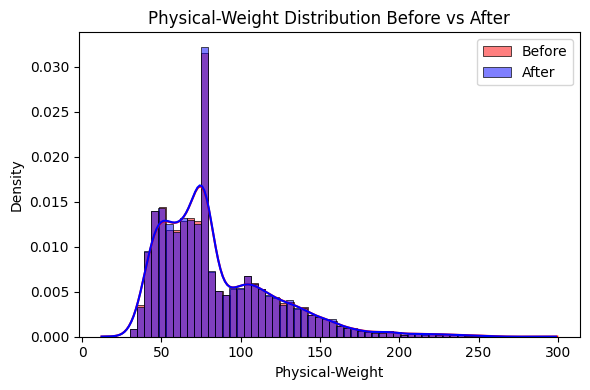

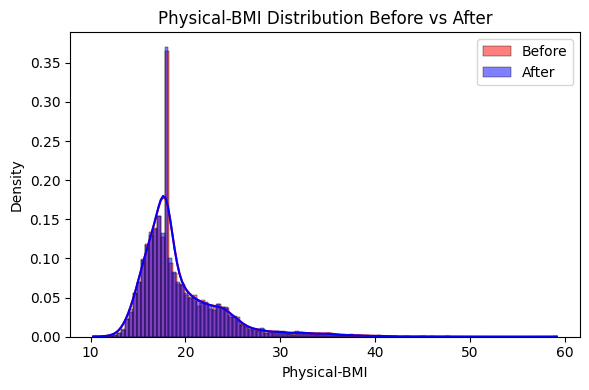

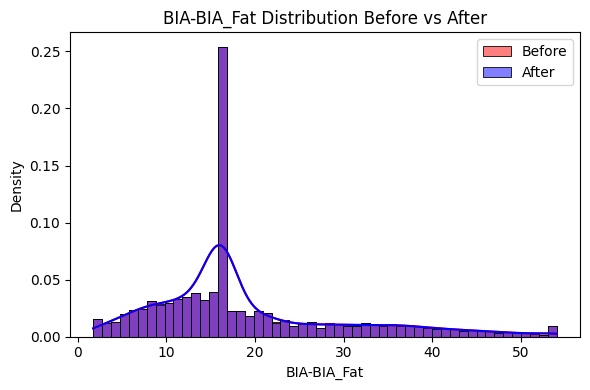

In [ ]:
cols_to_plot = ['Physical-Weight', 'Physical-BMI', 'BIA-BIA_Fat']

for col in cols_to_plot:
    plt.figure(figsize=(6,4))

    sns.histplot(df[col], color='red', label='Before', kde=True, stat='density')
    sns.histplot(df_clean[col], color='blue', label='After', kde=True, stat='density')

    plt.title(f'{col} Distribution Before vs After')
    plt.legend()
    plt.tight_layout()
    plt.show()

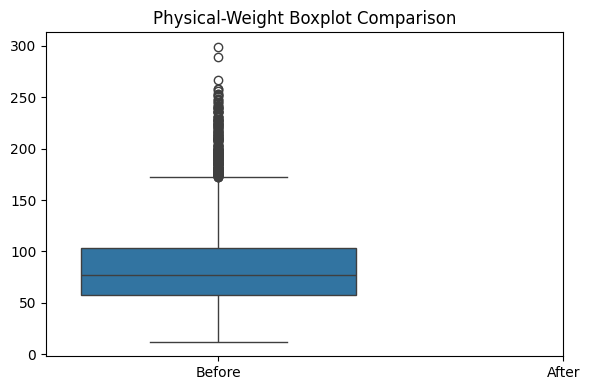

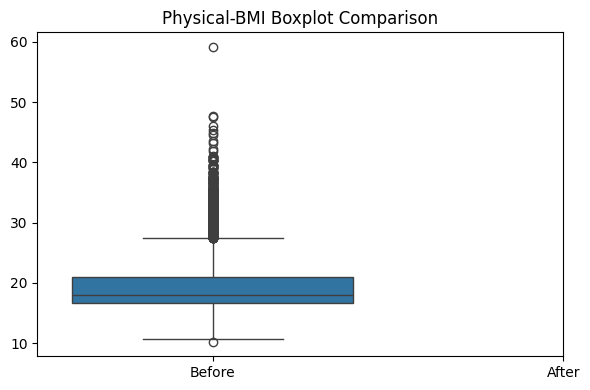

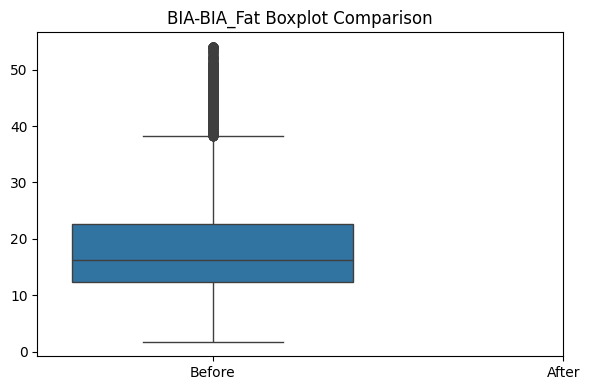

In [ ]:
for col in cols_to_plot:
    plt.figure(figsize=(6,4))

    sns.boxplot(data=[df[col], df_clean[col]])
    plt.xticks([0,1], ['Before', 'After'])

    plt.title(f'{col} Boxplot Comparison')
    plt.tight_layout()
    plt.show()

In [ ]:
for col in cols_to_plot:
    print(f"{col}")
    print(f"Before max: {df[col].max()}")
    print(f"After  max: {df_clean[col].max()}")
    print("-"*30)

Physical-Weight
Before max: 299.6
After  max: 298.8
------------------------------
Physical-BMI
Before max: 59.13204775
After  max: 59.13204775
------------------------------
BIA-BIA_Fat
Before max: 54.03679030997377
After  max: 54.03679030997377
------------------------------


In [ ]:
extreme_weight = df_clean[df_clean['Physical-Weight'] >= 250]

print(f"Number of rows ≥ 250 weight: {len(extreme_weight)}")

extreme_weight[['Basic_Demos-Age',
                'Basic_Demos-Sex',
                'Physical-BMI',
                'Physical-Height',
                'Physical-Weight']].sort_values(by='Physical-Weight', ascending=False)

Number of rows ≥ 250 weight: 11


,Basic_Demos-Age,Basic_Demos-Sex,Physical-BMI,Physical-Height,Physical-Weight
304,16,0,46.102914,67.5,298.8
1202,21,1,47.603772,65.4,289.6
3076,20,0,38.335020,70.0,267.2
1964,16,0,37.549609,69.5,258.0
1713,19,0,37.015102,70.0,258.0
8349,7,1,29.985932,68.0,256.0
2228,15,0,39.036269,67.5,253.0
2671,19,0,29.588912,77.5,252.8
1619,18,0,37.180298,69.0,251.8
3165,15,0,37.150767,69.0,251.6


In [ ]:
extreme_weight.sort_values(by='Physical-Weight', ascending=False)

,Basic_Demos-Age,Basic_Demos-Sex,CGAS-CGAS_Score,Physical-BMI,Physical-Height,Physical-Weight,Physical-Waist_Circumference,Physical-Diastolic_BP,Physical-HeartRate,Physical-Systolic_BP,...,FGC_Grip_Avg,PAQ_Total,SDS_measured,BIA_measured,FGC_Muscular_Endurance,Social_Digital_Displacement,Lifestyle_Risk_Score,Metabolic_Alarms_Count,ScreenTime_Age_Ratio,ScreenTime_Category
304,16,0,65.0,46.102914,67.5,298.8,49.0,72.0,93.0,157.0,...,34.600,1.38,1,1,5.50,0.400000,1.630168,4,0.176471,2
1202,21,1,40.0,47.603772,65.4,289.6,48.0,88.0,88.0,139.0,...,20.050,2.01,0,1,6.00,0.200000,0.982226,2,0.045455,1
3076,20,0,53.0,38.335020,70.0,267.2,26.0,62.0,93.0,149.0,...,20.625,2.01,1,1,6.00,0.317460,1.072226,2,0.095238,1
1964,16,0,71.0,37.549609,69.5,258.0,46.0,77.0,78.0,146.0,...,30.600,1.25,1,1,6.50,0.246914,1.374444,3,0.117647,1
1713,19,0,65.0,37.015102,70.0,258.0,45.0,83.0,78.0,147.0,...,21.200,2.01,1,1,6.00,0.000000,0.882226,2,0.000000,0
8349,7,1,70.0,29.985932,68.0,256.0,27.5,69.7,87.5,114.5,...,31.500,2.00,1,1,1.25,0.125000,1.028333,2,0.125000,1
2228,15,0,65.0,39.036269,67.5,253.0,49.0,86.0,82.0,134.0,...,28.200,1.02,0,1,0.00,0.266667,1.245050,3,0.125000,1
2671,19,0,75.0,29.588912,77.5,252.8,26.0,65.0,60.0,128.0,...,20.050,2.54,0,1,6.00,0.352941,1.132486,3,0.150000,2
1619,18,0,65.0,37.180298,69.0,251.8,48.0,85.0,75.0,131.0,...,35.250,2.96,0,1,5.00,0.266667,1.002525,3,0.105263,1
3165,15,0,85.0,37.150767,69.0,251.6,42.9,66.0,91.0,126.0,...,25.650,1.81,1,1,5.00,0.210526,1.045872,3,0.125000,1


In [ ]:
check_extreme = df[df['Physical-Weight'] >= 250][
    ['Basic_Demos-Age', 'Physical-Height', 'Physical-Weight', 'Physical-BMI']
].copy()

check_extreme['BMI_recomputed'] = (
    check_extreme['Physical-Weight'] / (check_extreme['Physical-Height'] ** 2)
) * 703

check_extreme['BMI_diff'] = check_extreme['BMI_recomputed'] - check_extreme['Physical-BMI']

check_extreme.sort_values('Physical-Weight', ascending=False)

,Basic_Demos-Age,Physical-Height,Physical-Weight,Physical-BMI,BMI_recomputed,BMI_diff
921,16,62.5,299.6,53.918413,53.918413,7.105427e-15
306,16,67.5,298.8,46.102914,46.102914,2.469136e-10
1212,21,65.4,289.6,47.603772,47.599061,-4.711131e-03
2215,14,66.5,282.0,44.829216,44.829216,-3.114927e-09
3098,20,70.0,267.2,38.335020,38.335020,-1.836739e-09
2958,16,71.8,259.2,35.346094,35.346094,-7.701715e-10
1723,19,70.0,258.0,37.015102,37.015102,8.163212e-10
1976,16,69.5,258.0,37.549609,37.549609,3.476522e-09
2553,17,70.5,257.0,36.354083,36.350485,-3.597802e-03
8391,7,68.0,256.0,29.985932,38.920415,8.934483e+00


one row with age 7 and extreme weigth was not good as there was difference in bmi so had to drop it

In [ ]:
df_clean = df_clean[df_clean.index != 8391].reset_index(drop=True)

In [ ]:
df_clean.shape

(8417, 32)

In [ ]:
# ── Save final clean dataset ──────────────────────────────────────
# Run after choosing your treatment above

df_clean.to_csv('cmi_module1_clean-1.csv', index=False)
print(f"Saved: cmi_module1_clean-1.csv — shape: {df_clean.shape}")

Saved: cmi_module1_clean-1.csv — shape: (8417, 32)
